### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, SpectralClustering

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

import scipy.cluster.hierarchy as sch

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

import warnings
warnings.filterwarnings('ignore')

### Просмотр набора данных

In [2]:
df = pd.read_csv('pokemon.csv')
df

,Name,Total,HP,Attack,Defence,Sp_attack,Sp_defence,Speed
0,Bulbasaur,318,45,49,49,65,65,45
1,Ivysaur,405,60,62,63,80,80,60
2,Venusaur,525,80,82,83,100,100,80
3,Mega Venusaur,625,80,100,123,122,120,80
4,Charmander,309,39,52,43,60,50,65
...,...,...,...,...,...,...,...,...
1040,Glastrier,580,100,145,130,65,110,30
1041,Spectrier,580,100,65,60,145,80,130
1042,Calyrex,500,100,80,80,80,80,80
1043,Mega Calyrex,680,100,165,150,85,130,50


### Описание данных

- name - имя покемона
- hp - здоровье
- attack - сила
- defence - количество защиты
- sp_attack - сила специальной атаки
- sp_defence - количество специальной защиты
- speed - скорость

Целевая переменная:
- total - сумма всех характеристик

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045 entries, 0 to 1044
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        1045 non-null   object
 1   Total       1045 non-null   int64 
 2   HP          1045 non-null   int64 
 3   Attack      1045 non-null   int64 
 4   Defence     1045 non-null   int64 
 5   Sp_attack   1045 non-null   int64 
 6   Sp_defence  1045 non-null   int64 
 7   Speed       1045 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 65.4+ KB


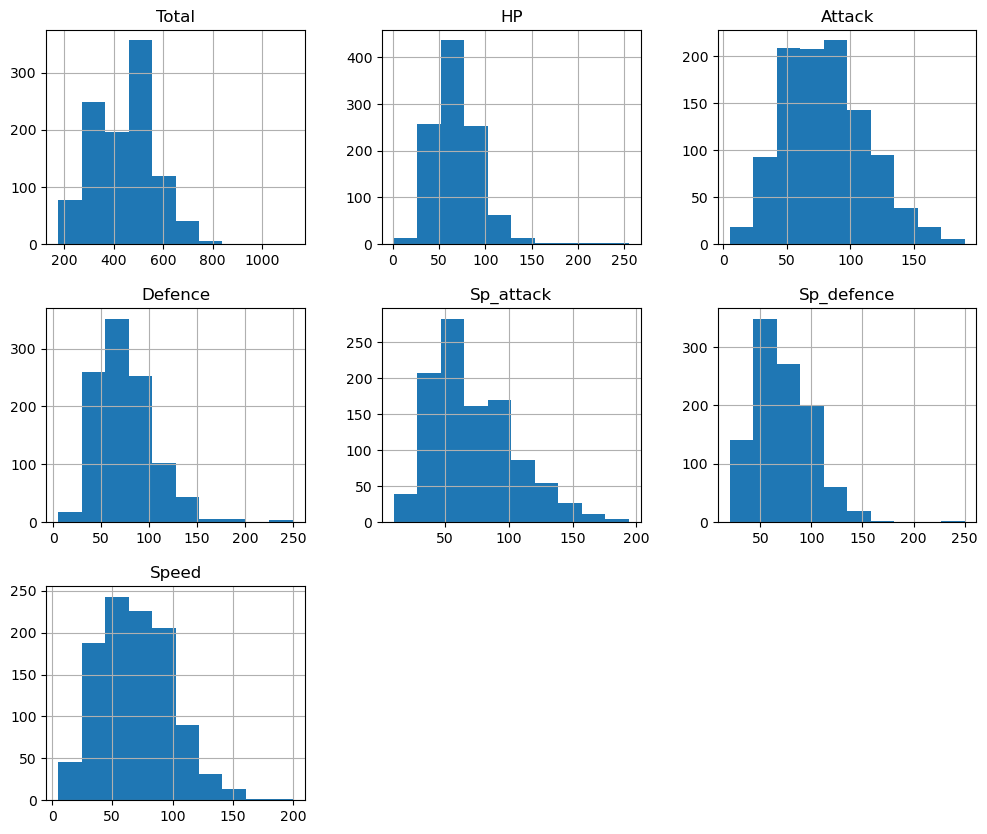

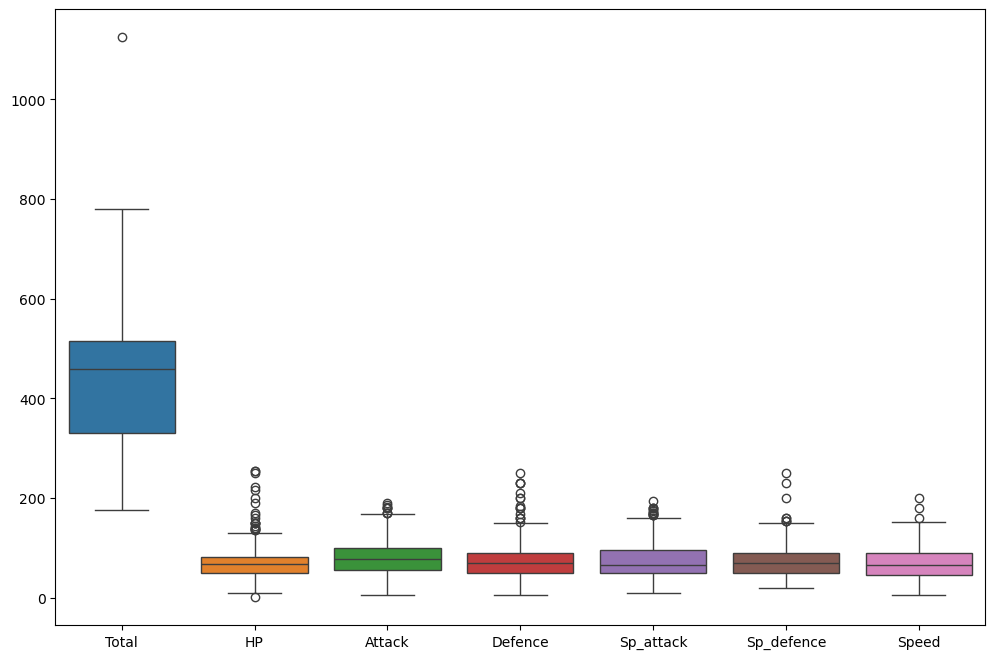

In [3]:
# Гистограммы для числовых переменных
df.hist(figsize=(12, 10))
plt.show()
# Boxplot для числовых переменных
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.show()

In [4]:
df.duplicated().sum()

5

In [5]:
df = df.drop_duplicates()

In [7]:
df.describe()

,HP,Attack,Defence,Sp_attack,Sp_defence,Speed
count,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000
mean,70.121154,80.531731,74.576923,72.908654,72.193269,68.733654
std,26.713263,32.477622,31.263940,32.748911,28.079396,30.259182
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000
50%,68.000000,78.000000,70.000000,65.000000,70.000000,65.000000
75%,83.000000,100.000000,90.000000,95.000000,90.000000,90.000000
max,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000


### Идентификация корреляций между переменными

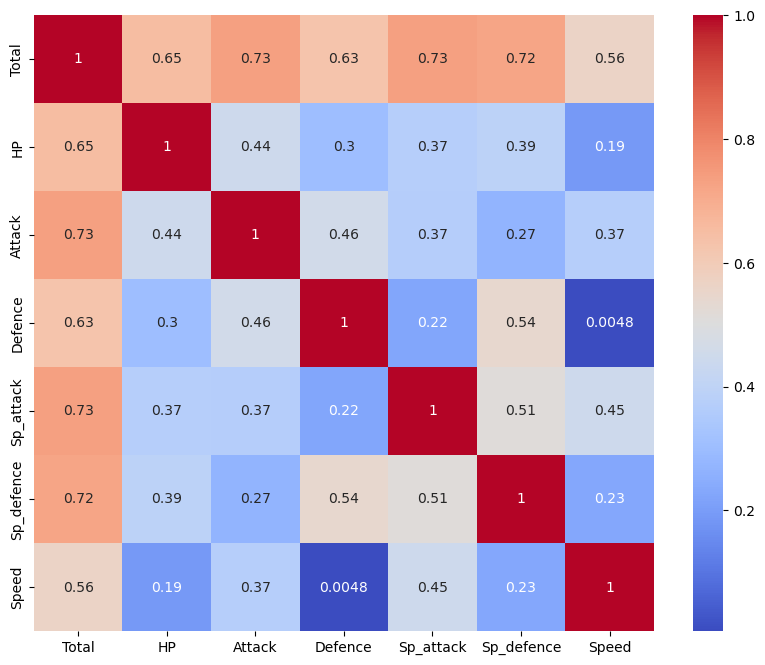

In [4]:
# Матрица корреляций
corr_matrix = df.drop(columns=['Name']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

### Нормализация

In [9]:
mms = MinMaxScaler()
df=pd.DataFrame(mms.fit_transform(df), columns=df.columns)

### Метод главных компонентов

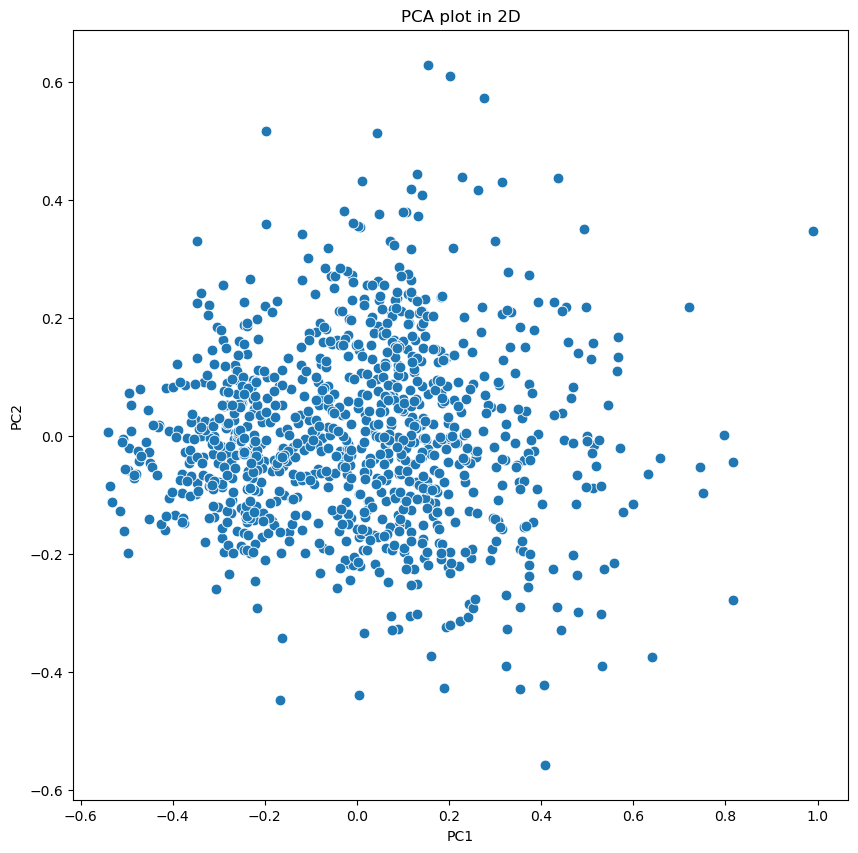

In [10]:
principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(df))
    
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                s=60)

plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

In [11]:
def TSNEplot(pred=None):    
    tsne = TSNE(random_state=1)
    X_tsne = tsne.fit_transform(df)

    plt.figure(figsize=(12, 10))
    plt.scatter(X_tsne[:, 0], 
                X_tsne[:, 1], 
                c = pred, 
                edgecolor="none", 
                alpha=0.7, s=40,
        cmap=plt.cm.get_cmap("flare", 3))

    plt.colorbar()
    plt.title("t-SNE projection");

  File "C:\Users\robhul\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\robhul\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\robhul\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\robhul\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


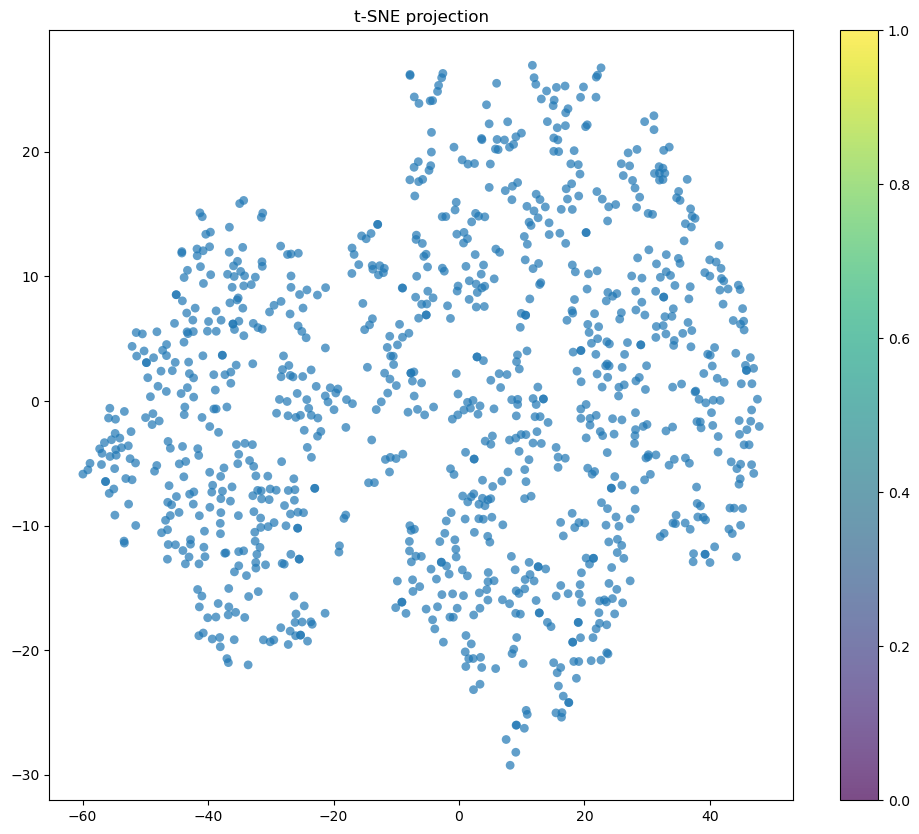

In [12]:
TSNEplot()

### K-Means

In [13]:
pca = PCA(n_components=2)

kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto').fit(df)
centroids_pca = pca.fit_transform(kmeans.cluster_centers_)
pred_k = kmeans.labels_

principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(df))

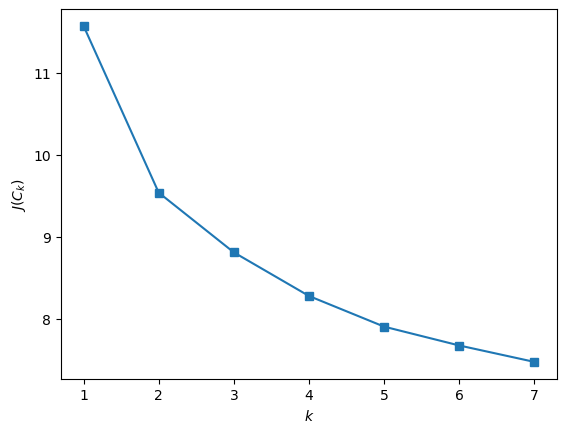

In [14]:
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1, n_init='auto').fit(df)
    inertia.append(np.sqrt(kmeans.inertia_))
    
plt.plot(range(1, 8), inertia, marker="s")
plt.xlabel("$k$")
plt.ylabel("$J(C_k)$");

In [15]:
pca = PCA(n_components=2)


kmeans = KMeans(n_clusters=3, random_state=1, n_init='auto').fit(df)
centroids_pca = pca.fit_transform(kmeans.cluster_centers_)
pred_k = kmeans.labels_

principal_df = pd.DataFrame(data = PCA(n_components=2).fit_transform(df))

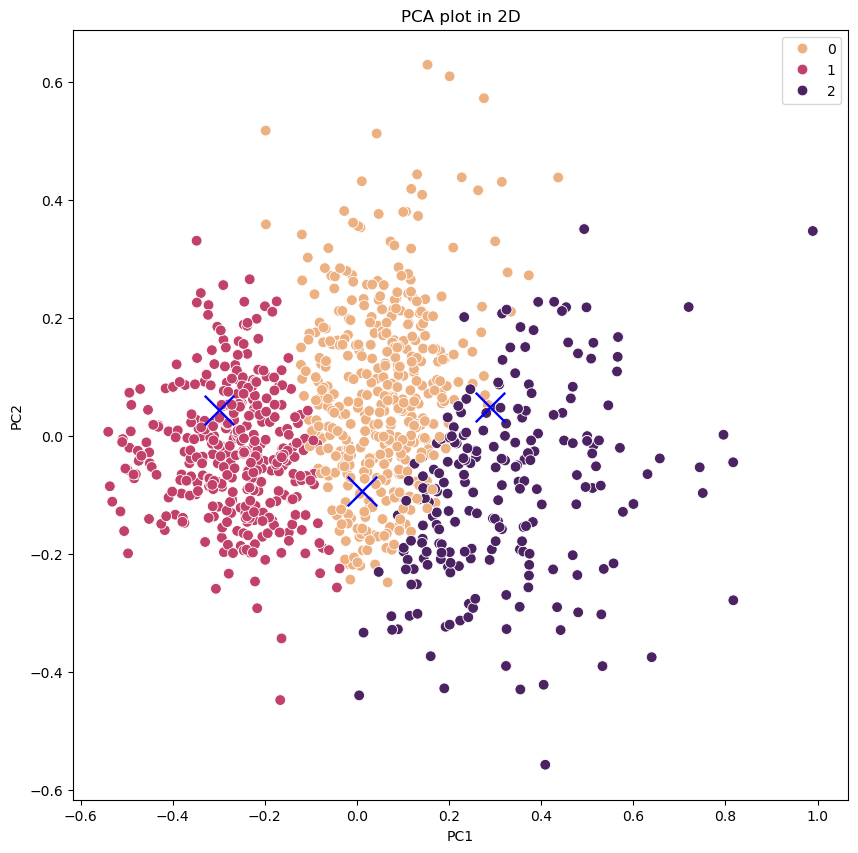

In [16]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_k, 
                palette="flare", 
                s=60)
sns.scatterplot(x = centroids_pca[:,0], 
                y =  centroids_pca[:,1],  
                marker="x", 
                s=450, 
                color = 'blue')
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

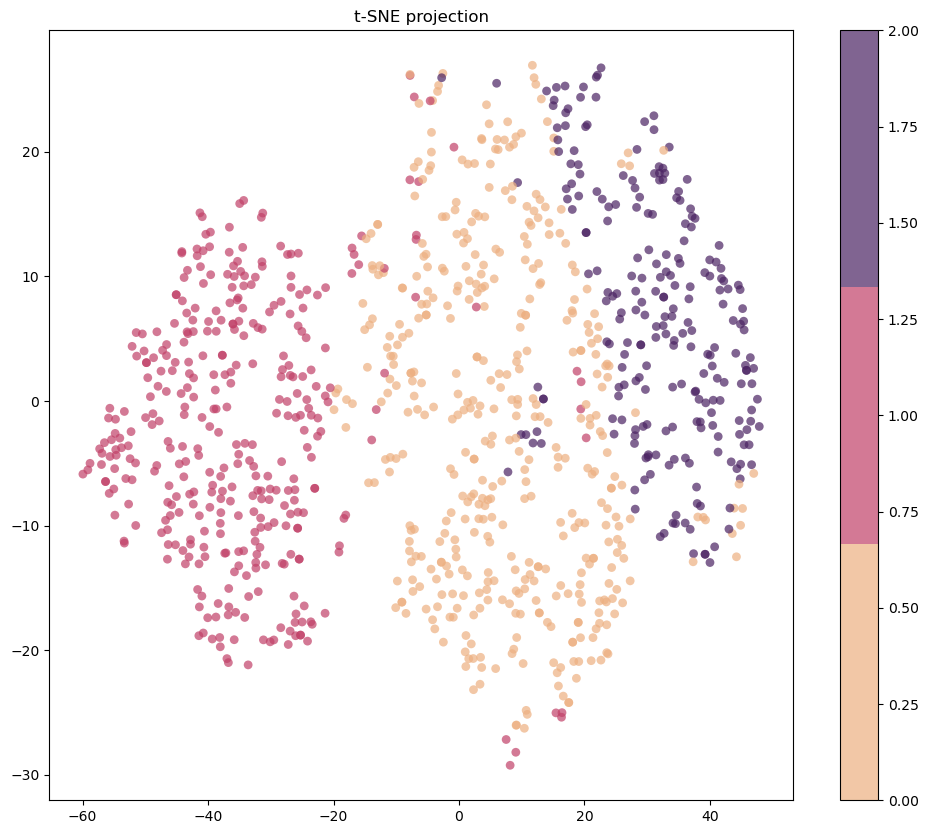

In [17]:
TSNEplot(pred_k)

### Agglomerative Clustering by Ward

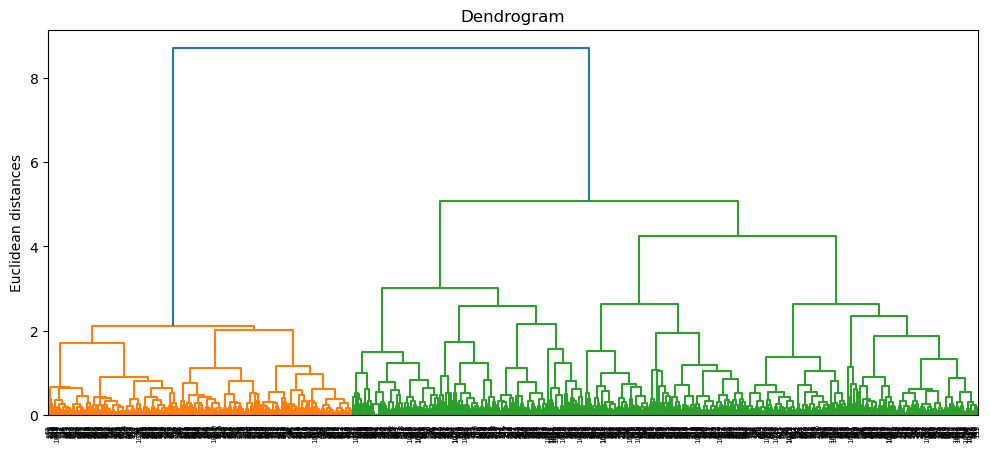

In [18]:
plt.figure(figsize=(12, 5))
dendrogram = sch.dendrogram(sch.linkage(df, method = 'ward'))
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.show()

In [19]:
clustering_ward = AgglomerativeClustering(3).fit(df)
pred_ward = clustering_ward.labels_

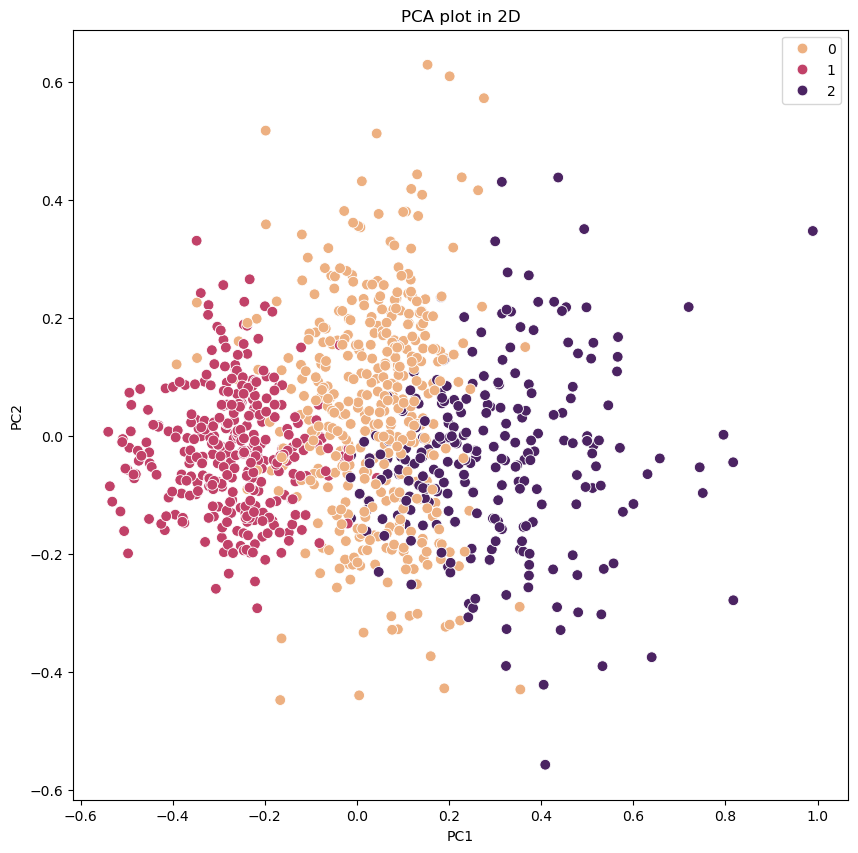

In [20]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_ward, 
                palette="flare", 
                s=60)
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

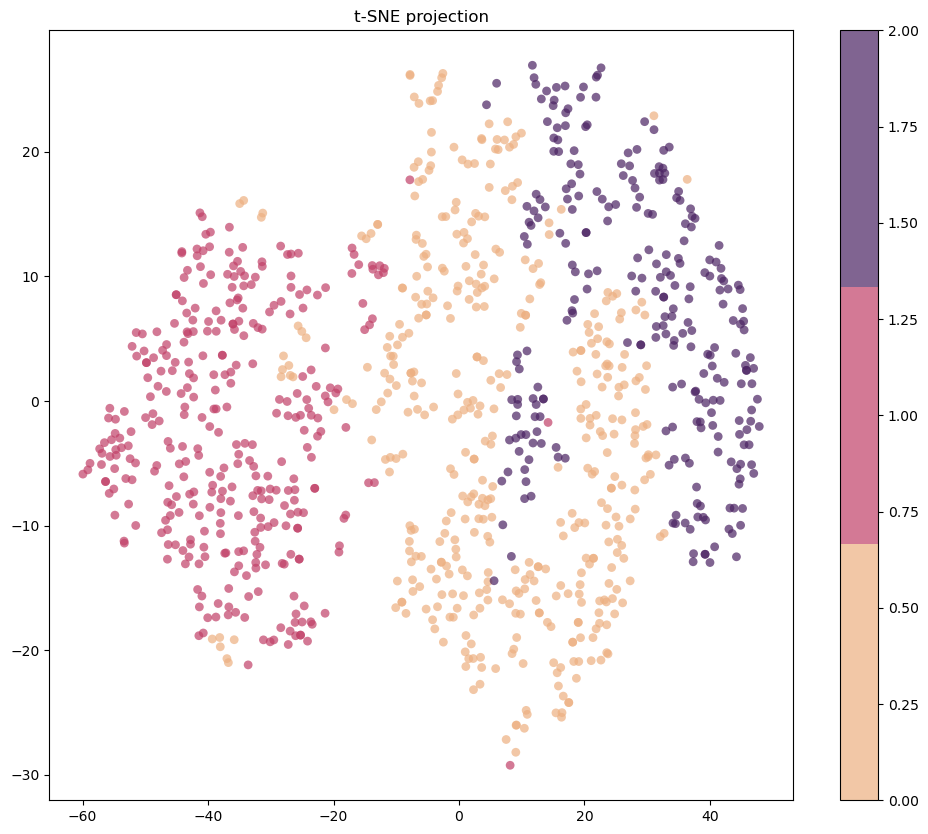

In [21]:
TSNEplot(pred_ward)

### Spectral Clustering

In [22]:
clustering_sp = SpectralClustering(3).fit(df)
pred_sp = clustering_sp.labels_

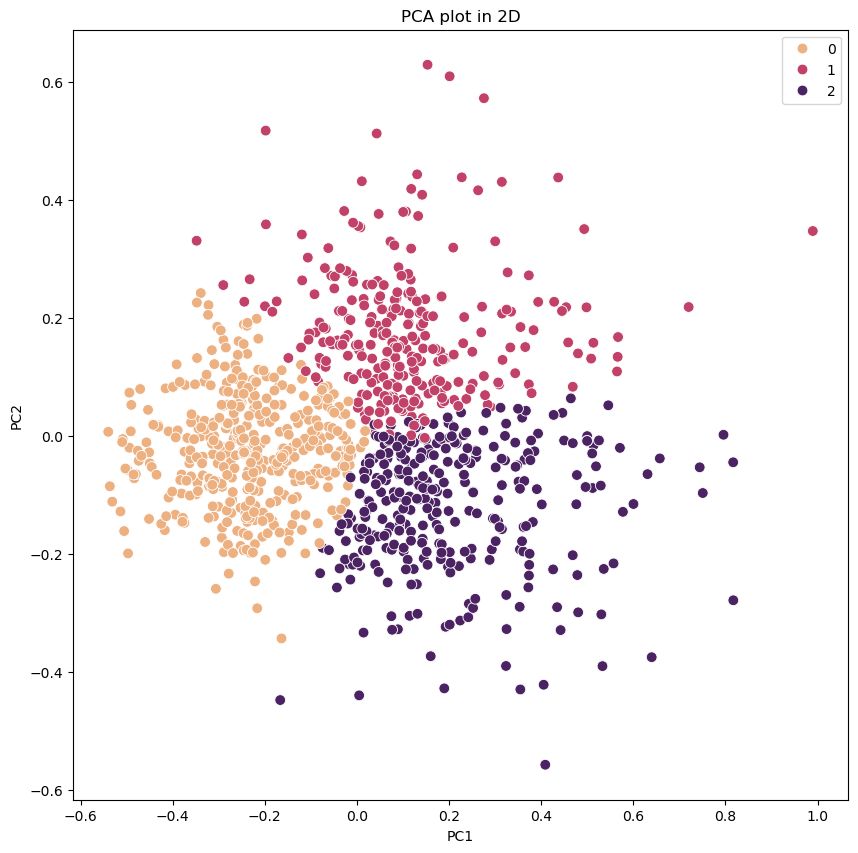

In [23]:
fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x = principal_df.iloc[:,0], 
                y = principal_df.iloc[:,1], 
                hue = pred_sp, 
                palette="flare", 
                s=60)
plt.title('PCA plot in 2D')
plt.xlabel('PC1')
plt.ylabel('PC2');

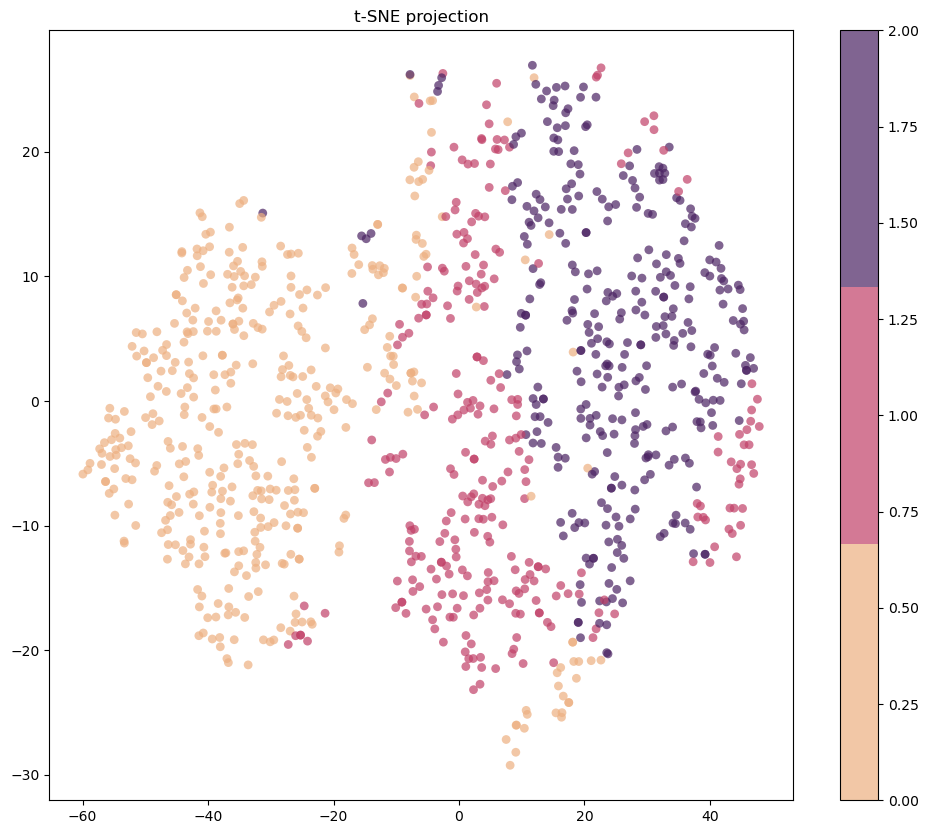

In [24]:
TSNEplot(pred_sp)

### Классификация